
**Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

**Edición 2023**

---

# Trabajo práctico entregable - Parte 2

In [281]:
import itertools
import io
import matplotlib
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from matplotlib.ticker import FuncFormatter
from scipy.stats import skew

sns.set_context('talk')

## Lectura del dataset

En la notebook 00 se explican los detalles de la siguiente sección.

Antes de empezar, podemos establecer la cantidad de decimales que usaremos en la expresion de valores numéricos, con el siguiente comando.

In [282]:
pd.set_option('display.float_format', lambda x: '%.0f' % x)  # suppress scientific notation 

Descargamos el set de datos y lo guardamos en un DataFrame para luego ir trabajando con ellos.

In [283]:
url = 'https://raw.githubusercontent.com/brivadeneira/diplo-notes/main/salary_vs_programming_languages/preprocessed_salaries_dataset.csv'
df = pd.read_csv(url)

In [284]:
df

,work_dedication,salary_comparison_last_semester,profile_level_study,profile_gender,profile_experience_range,list_of_normalized_languages,usd_monthly_gross_salary
0,part-time,2,Universitario,M,0-1,['sql'],210
1,part-time,1,NaN,M,1-2,"['css', 'html', 'java', 'python', 'sql']",191
2,part-time,3,Universitario,M,1-2,"['javascript', 'python', 'sql']",846
3,part-time,2,Universitario,M,0-1,"['javascript', 'sql']",496
4,part-time,3,Universitario,M,1-2,['javascript'],345
...,...,...,...,...,...,...,...
3338,full-time,4,Universitario,M,6-10,"['.net', 'c#', 'java', 'javascript']",1144
3339,full-time,2,Universitario,F,3-5,"['python', 'sql']",419
3340,full-time,3,NaN,F,0-1,['sql'],457
3341,full-time,2,NaN,F,6-10,"['html', 'sql']",877


Antes de empezar el analisis, hay que dividir el DataFrame en dos categorias, aquellos que tienen dedicacion "Full Time" y aquellos que tienen dedicacion "Part Time". Esto es debido a que hay una clara diferencia entre los salrios de aquellos  que  tienen una dedicacion exclusiva, y aquellos que trabajan menos horas u ocasionalmente.

In [285]:
df_part = df.groupby('work_dedication').get_group('part-time')
df_full = df.groupby('work_dedication').get_group('full-time')

Ahora podemos analizar los estadisticos de cada genero, en cada categoria.

In [286]:
df_part[['profile_gender', 'usd_monthly_gross_salary']].groupby('profile_gender').describe()

usd_monthly_gross_salary                              
                                  count mean std min 25% 50% 75%  max
profile_gender                                                       
F                                    20  485 319 130 264 381 562 1257
M                                   111  639 556 168 337 477 729 3431
X                                     3  437 249 282 294 305 515  724

In [287]:
df_full[['profile_gender', 'usd_monthly_gross_salary']].groupby('profile_gender').describe()

usd_monthly_gross_salary                                 
                                  count mean  std min 25%  50%  75%  max
profile_gender                                                          
F                                   477 1032  717 259 573  839 1220 5947
M                                  2681 1415 1074 252 735 1144 1716 9664
X                                    51 1154  806 343 608  904 1413 4956

Hay que notar la marcada difererencia de valores que existe entre aquellos con dedicacion Full-time, y los que tienen dedicacion Part-time. 

Primero vamos a analizar que pasa con los salarios de aquellas personas que tienen dedicacion Full-time, puesto que estas son mas representativas debido al numero de muestras que se tiene, y al hecho de que al dedicarse exclusivamente a la programacion, puede obtenerse informacion mas fidedigna. 
Luego, y solo con intencion de comentar, vamos a ver que sucede con los salarios por genero de aquellas personas que tienen un trabajo Part-time.

Definimos un funcion y algunos parametros que nos serviran para darles formatos a los numeros en los graficos que vayamos generando

In [288]:
def human_format(num, pos=1):
    """
    human formatting for big numbers
    """
    magnitude = 0
    while abs(num) >= 1000:
        magnitude += 1
        num /= 1000.0
    return "%.0f%s" % (num, ["", "K", "M", "G", "T", "P"][magnitude])


FORMATTER = FuncFormatter(human_format)

In [289]:
FIGSIZE, VSUBPLOTS_FIGSIZE, HSUBPLOTS_FIGSIZE, DPI = (12, 5), (15, 10), (15, 4), 100
PASTEL_PALETTE = sns.color_palette('pastel')
MAIN_PALETTE = itertools.cycle(PASTEL_PALETTE)
CATEGORICAL_PALETTE = sns.color_palette('Set2')
SECUENTIAL_PALETTE = sns.color_palette('flare')

statistics_of_interest = ['mean', 'std', '25%', '50%', '75%']

Podemos comenzar el analisis de los salarios Full-time por genero haciendo una visualizacion para ver como es la distribucion de los mismos

In [290]:
is_man_f = df_full.profile_gender == 'M'

df_full_man = df_full[is_man_f]
df_full_not_man = df_full[~is_man_f]

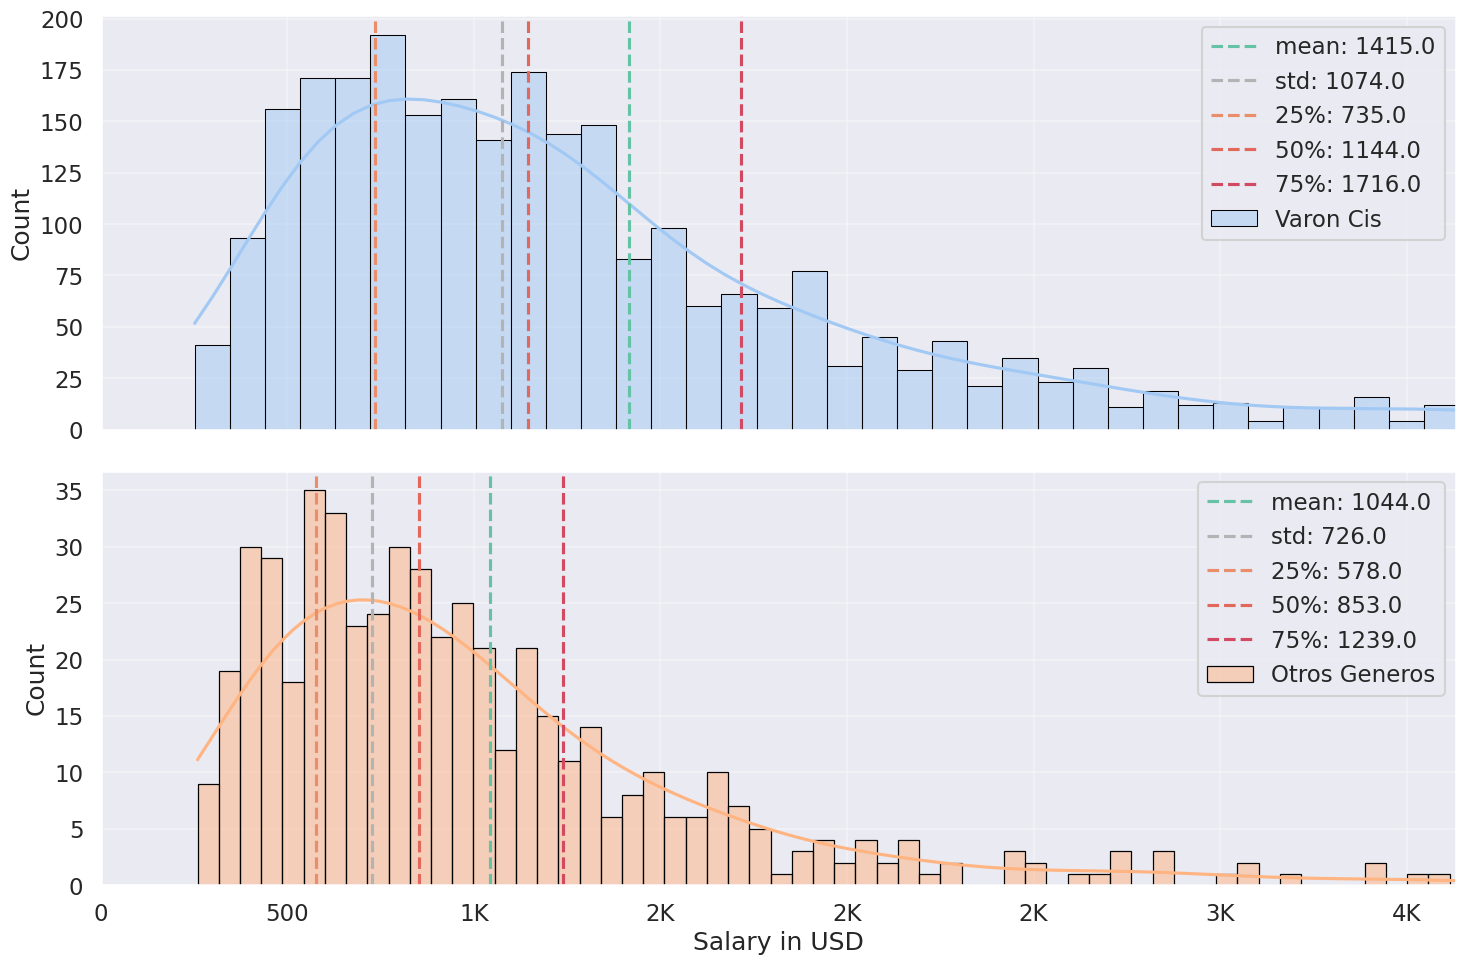

In [291]:
f, ax = plt.subplots(2, 1, figsize=VSUBPLOTS_FIGSIZE, dpi=DPI, sharex=True)

n_bins = 100
df_name = ['Varon Cis', 'Otros Generos']

for i, df in enumerate([df_full_man, df_full_not_man]):
    
    df_std = df.usd_monthly_gross_salary.std()

    sns.histplot(df,
                 x='usd_monthly_gross_salary',
                 bins=n_bins,
                 ax=ax[i],
                 label=df_name[i],
                 color=next(MAIN_PALETTE),
                 edgecolor='black',  # this is not working well...
                 kde=True
                 )
    
    statistics = df.usd_monthly_gross_salary.describe(include='all')

    for j, name in enumerate(['mean', 'std']):
        statistic = statistics[name]
        ax[i].axvline(statistic,
                      label=f'{name}: {round(statistic,0)}',
                      color=CATEGORICAL_PALETTE.as_hex()[-j],
                      linestyle='dashed')
        
    for j, st in enumerate(['25%', '50%', '75%']):
        statistic = statistics[st]
        ax[i].axvline(statistic,
                      label=f'{st}: {round(statistic,0)}',
                      color=SECUENTIAL_PALETTE.as_hex()[j],
                      linestyle='dashed')
        
    ax[i].xaxis.set_major_formatter(FORMATTER)
    ax[i].grid(alpha=0.3)
    ax[i].legend()
    ax[i].set_xlim(0, 5 * df_std)

    plt.xlabel('Salary in USD')

plt.tight_layout()

Es evidente que el promedio salarial es mayor para varones que para el resto de la poblacion. Sin embargo, puede resultar confusa la comparacion, debido a la gran diferencia de tamaños de las muestras de cada género. 

Para solucionarlo, podemos tomar una submuestra del tamaño de la muestra de otros generos, analizar si es representativa de la muestra original.

In [292]:
df_full_man_sub = df_full_man.sample(n=len(df_full_not_man), random_state=42)

In [293]:
df_full_man_sub

,work_dedication,salary_comparison_last_semester,profile_level_study,profile_gender,profile_experience_range,list_of_normalized_languages,usd_monthly_gross_salary
894,full-time,2,NaN,M,10+,['java'],1334
2175,full-time,1,NaN,M,1-2,"['.net', 'c#', 'css', 'javascript', 'php']",534
1943,full-time,2,NaN,M,3-5,['bash/shell'],572
2363,full-time,1,NaN,M,3-5,"['.net', 'css', 'html', 'javascript', 'php', '...",586
357,full-time,2,NaN,M,10+,"['c++', 'c#', 'sql']",1144
...,...,...,...,...,...,...,...
1851,full-time,4,Secundario,M,1-2,"['javascript', 'typescript']",1525
2817,full-time,2,Universitario,M,10+,"['java', 'php', 'sql', 'vba']",1144
1124,full-time,2,NaN,M,6-10,"['bash/shell', 'css', 'html']",1430
1887,full-time,2,NaN,M,3-5,"['java', 'javascript', 'r']",1299


Podemos ahora comparar los estadisticos de la muestra y la submuestra para ver si efectivamente esta ultimma es representativa.

In [294]:
pd.concat(
    [df_full_man.usd_monthly_gross_salary.describe(), 
    df_full_man_sub.usd_monthly_gross_salary.describe()],
    axis=1, keys=['Muestra_Varones_Cis', 'Submuestra']
          )

,Muestra_Varones_Cis,Submuestra
count,2681,528
mean,1415,1494
std,1074,1181
min,252,284
25%,735,751
50%,1144,1144
75%,1716,1762
max,9664,8387


Viendo la cercania entre los valores medios, podemos concluir que la submuestra representa muy bien a la muestra original, cosa que es verdad. Sin embargo, llegados a este punto, cabe aclarar que cada una de las diferentes medidas estadisticas (media muestral, mediana y moda), tienen sus ventajas y desventajas, que deben ser tenidas en cuenta para determinar cuando resulta conveniente utilizar alguna, desechando las restantes. 

En este caso, la distribucion de frecuencias es notoriamente asimetrica hacia la izquierda, por lo que la media muestral no es el estimador mas apropiado, debido a su sensibilidad a unos pocos valores extremos. Mas apropiado es utilizar o la Mediana o la Moda, que al no ser afectados por valores extremos, es mas representativa de la muestra.
Elijamos la Mediana y comparemos con la media.

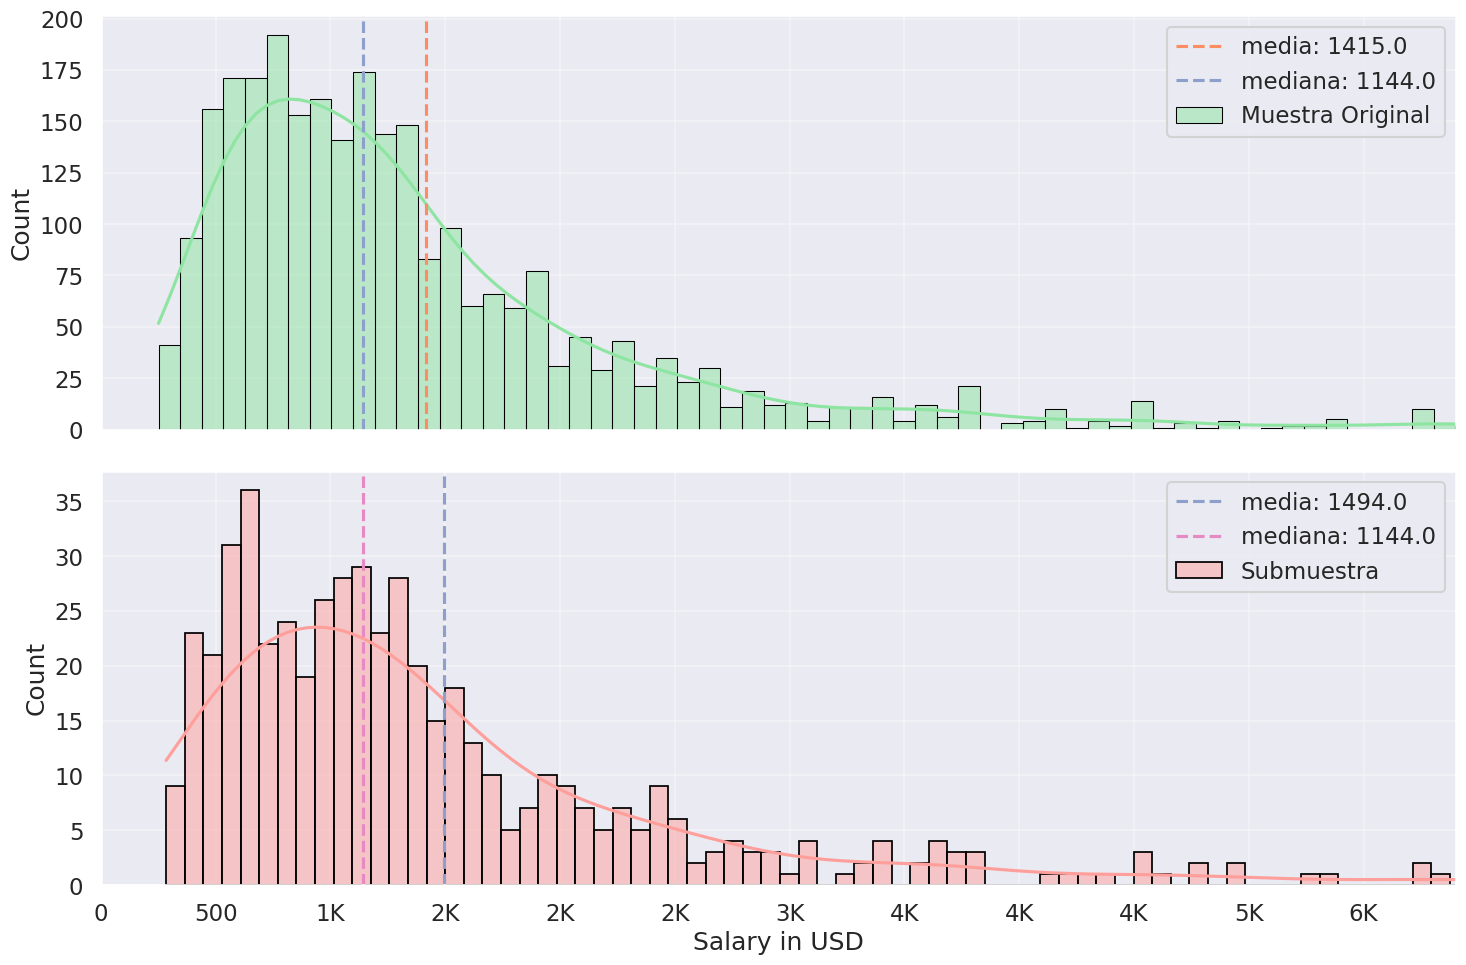

In [295]:
f, ax = plt.subplots(2, 1, figsize=VSUBPLOTS_FIGSIZE, dpi=DPI, sharex=True)

n_bins = 100
df_name = ['Muestra Original', 'Submuestra']

for i, df in enumerate([df_full_man, df_full_man_sub]):
    
    df_std = df.usd_monthly_gross_salary.std()

    sns.histplot(df,
                 x='usd_monthly_gross_salary',
                 bins=n_bins,
                 ax=ax[i],
                 label=df_name[i],
                 color=next(MAIN_PALETTE),
                 edgecolor='black',  # this is not working well...
                 kde=True
                 )
    
    ax[i].axvline(df.usd_monthly_gross_salary.mean(),
                      label=f'media: {round(df.usd_monthly_gross_salary.mean(),0)}',
                      color=CATEGORICAL_PALETTE.as_hex()[i+1],
                      linestyle='dashed')
    ax[i].axvline(df.usd_monthly_gross_salary.median(),
                      label=f'mediana: {round(df.usd_monthly_gross_salary.median(),0)}',
                      color=CATEGORICAL_PALETTE.as_hex()[i+2],
                      linestyle='dashed')
    
        
    ax[i].xaxis.set_major_formatter(FORMATTER)
    ax[i].grid(alpha=0.3)
    ax[i].legend()
    ax[i].set_xlim(0, 5 * df_std)
    ax[i].set_xticks(np.arange(0,5 * df_std,500) )

    plt.xlabel('Salary in USD')

plt.tight_layout()
plt.show()

Efectivamente vemos que, aunque las medias muestrales soon cercanas, las medianas de ambas muestras coinciden exactamente. Habiendo elegido esta medida como estimador mas representativo, podemos deducir que la submuestra es representativa de la muestra original(cosa que ya intuiamos al ver las medias) . 
Entonces, de ahora en mas haremos las comparacion entre muestras del mismo tamaño, tomando submuestras de aquellas con mayor tamaño.

## Ejercicio 1: Estimación

**Consigna:**  Calcular una estimación puntual y un intervalo de confianza de nivel (1-alpha) para la resta entre la media del salario Neto para Hombres menos la media del salario Neto para otros géneros(diferencia de las medias entre el grupoA y grupoB). 
¿Cómo se relaciona este intervalo de confianza con el test de hipótesis?

Como dijimos, vamos a analizar primero que ocurre con las medias salariales de aquellos programadores que tienen una dedicacion Full-time, y luego vamos a analizar el caso de aquellos que tienen dedicacion Part_time. Ademas, vamos a usar la mediana como medida para estimar la media poblacional, apoyandonos en el hecho de que la media muestral no es representativa en muestra con distribucion asimetrica.

Vamos a suponer en primera instancia que las medidas muestrales cumplen una distribucion t de Student, y veamos que resultados podemos obtener. 
Primero calculo el estimador puntual de la diferencia poblacional de las medias salariales netas en dolares.

In [296]:
group_man_f = df_full_man_sub.usd_monthly_gross_salary
group_not_man_f = df_full_not_man.usd_monthly_gross_salary

In [297]:
diferencia_medias_f = group_man_f.median() - group_not_man_f.median()
diferencia_medias_f


290.83908352712433

Defino mi nivel de confianza.

In [298]:
alpha = 0.05

Hago el calculo de los grados de libertad de la distribucion t de student.

In [299]:
grad_de_lib_f = len(group_man_f) + len(group_not_man_f) - 2
grad_de_lib_f

1054

Calculamos ahora el valor t_alpha, a partir del valor de alphay los grados de libertad.

In [300]:
t_valor_f = stats.t.ppf(1 - alpha/2, grad_de_lib_f)
t_valor_f

1.9622172591365907

Calculo el error estandar que me servira para armar mi intervalo de confianza.

In [301]:
err_std_f = np.sqrt(group_man_f.var() + group_not_man_f.var()) / len(group_man_f)
err_std_f

2.6253263671375047

Calculo con estos valores, los extremos del intervalos de confianza.

In [302]:
inter_conf_t_stu_f = (diferencia_medias_f - t_valor_f * err_std_f, diferencia_medias_f + t_valor_f * err_std_f)
inter_conf_t_stu_f

(285.68762281866077, 295.9905442355879)

Entonces:

In [303]:
print(f"La diferencia de medias es {diferencia_medias_f:.0f}")
print(f"El intervalo de confianza del 95% para la diferencia de medias es ({inter_conf_t_stu_f[0]:.0f}, {inter_conf_t_stu_f[1]:.0f})")

La diferencia de medias es 291
El intervalo de confianza del 95% para la diferencia de medias es (286, 296)


Esto nos esta diciendo que efectivamente hay una diferencia entre los salarios en dolares de los varones, y otros generos, y que esta diferencia se encuentra aproximadamente entre los 285 y los 295 dolares. 

Supongamos ahora que, debido a los tamaños de las muestras, podemos considerar que las distribuciones muestrales obedecen una distribucion normal, dado por la Teorema del Limite Central. En teoria, a medida que el tamaño muestral aumenta, los resultados para la distribucion t de Student, deberian comportarse como una distribucion normal.
Veamos si esto es asi.

El valor del estimador sigue siendo el mismo, al igual que el nivel de confianza y el error estandar. Solo resta calcular el valor de z.

In [304]:
inter_conf_norm = stats.norm.interval(1-alpha, loc = diferencia_medias_f, scale = err_std_f)
inter_conf_norm

(285.69353839987144, 295.9846286543772)

Entonces:

In [305]:
print(f"La diferencia de medias es {diferencia_medias_f:.0f}")
print(f"El intervalo de confianza del 95% para la diferencia de medias es ({inter_conf_norm[0]:.0f}, {inter_conf_norm[1]:.0f})")

La diferencia de medias es 291
El intervalo de confianza del 95% para la diferencia de medias es (286, 296)


Vemos que los valores coinciden exactamente, cosa que era de esperarse, ya que estamos trabajando con muestras de tamaños grandes, que se pueden considerar que obedecen distribucion normales.

Hagamos ahora el mismo analisis, pero para aquellos trabajadores que tienen una dedicacion Part-time.

In [306]:
is_man_p = df_part.profile_gender == 'M'

df_part_man = df_part[is_man_p]
df_part_not_man = df_part[~is_man_p]

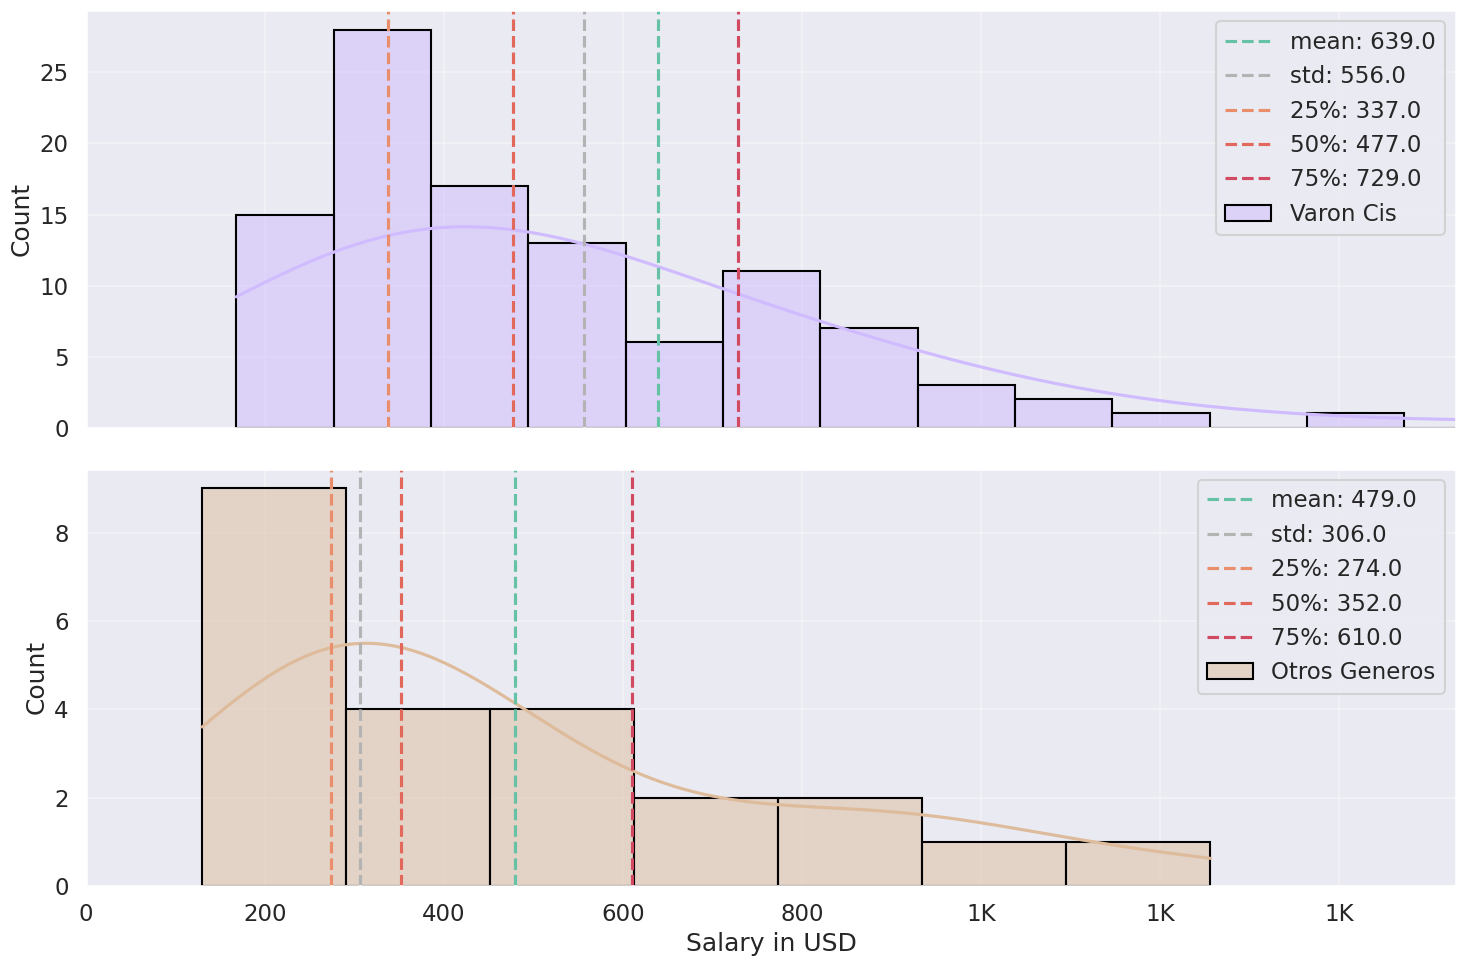

In [307]:
f, ax = plt.subplots(2, 1, figsize=VSUBPLOTS_FIGSIZE, dpi=DPI, sharex=True)

n_bins = [30,7]
df_name = ['Varon Cis', 'Otros Generos']

for i, df in enumerate([df_part_man, df_part_not_man]):
    
    df_std = df.usd_monthly_gross_salary.std()

    sns.histplot(df,
                 x='usd_monthly_gross_salary',
                 bins=n_bins[i],
                 ax=ax[i],
                 label=df_name[i],
                 color=next(MAIN_PALETTE),
                 edgecolor='black',
                 kde=True
                 )
    
    statistics = df.usd_monthly_gross_salary.describe(include='all')

    for j, name in enumerate(['mean', 'std']):
        statistic = statistics[name]
        ax[i].axvline(statistic,
                      label=f'{name}: {round(statistic,0)}',
                      color=CATEGORICAL_PALETTE.as_hex()[-j],
                      linestyle='dashed')
        
    for j, st in enumerate(['25%', '50%', '75%']):
        statistic = statistics[st]
        ax[i].axvline(statistic,
                      label=f'{st}: {round(statistic,0)}',
                      color=SECUENTIAL_PALETTE.as_hex()[j],
                      linestyle='dashed')
        
    ax[i].xaxis.set_major_formatter(FORMATTER)
    ax[i].grid(alpha=0.3)
    ax[i].legend()
    ax[i].set_xlim(0, 5 * df_std)

    plt.xlabel('Salary in USD')

plt.tight_layout()
plt.show()

Nuevamente, vamos a extraer una submuestra de la muestra de mayor tamaño, y vamos a ver si es representativa.

In [308]:
df_part_man_sub = df_part_man.sample(n=len(df_part_not_man), random_state=42)

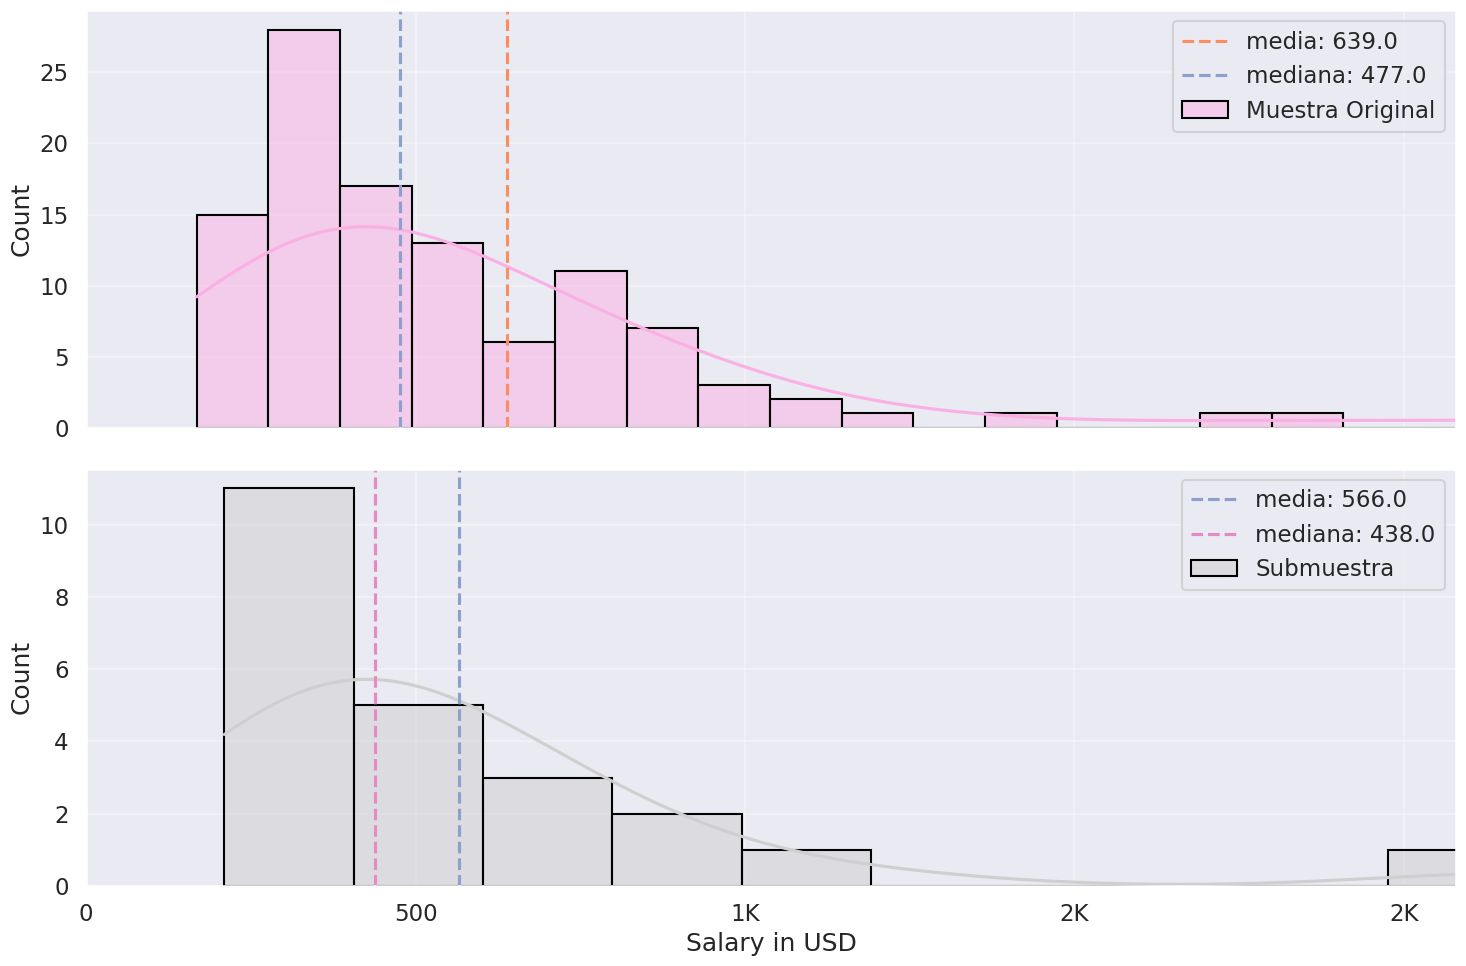

In [309]:
f, ax = plt.subplots(2, 1, figsize=VSUBPLOTS_FIGSIZE, dpi=DPI, sharex=True)

n_bins = [30,10]
df_name = ['Muestra Original', 'Submuestra']

for i, df in enumerate([df_part_man, df_part_man_sub]):
    
    df_std = df.usd_monthly_gross_salary.std()

    sns.histplot(df,
                 x='usd_monthly_gross_salary',
                 bins=n_bins[i],
                 ax=ax[i],
                 label=df_name[i],
                 color=next(MAIN_PALETTE),
                 edgecolor='black',  # this is not working well...
                 kde=True
                 )
    
    ax[i].axvline(df.usd_monthly_gross_salary.mean(),
                      label=f'media: {round(df.usd_monthly_gross_salary.mean(),0)}',
                      color=CATEGORICAL_PALETTE.as_hex()[i+1],
                      linestyle='dashed')
    ax[i].axvline(df.usd_monthly_gross_salary.median(),
                      label=f'mediana: {round(df.usd_monthly_gross_salary.median(),0)}',
                      color=CATEGORICAL_PALETTE.as_hex()[i+2],
                      linestyle='dashed')
    
        
    ax[i].xaxis.set_major_formatter(FORMATTER)
    ax[i].grid(alpha=0.3)
    ax[i].legend()
    ax[i].set_xlim(0, 5 * df_std)
    ax[i].set_xticks(np.arange(0,5 * df_std,500) )

    plt.xlabel('Salary in USD')

plt.tight_layout()
plt.show()

Otra vez, por la asimetria que tiene la grafica de distribucion, no es buena opcion elegir la media muestral como estimador. Veamos si es que las medianas se aproximan entre si.

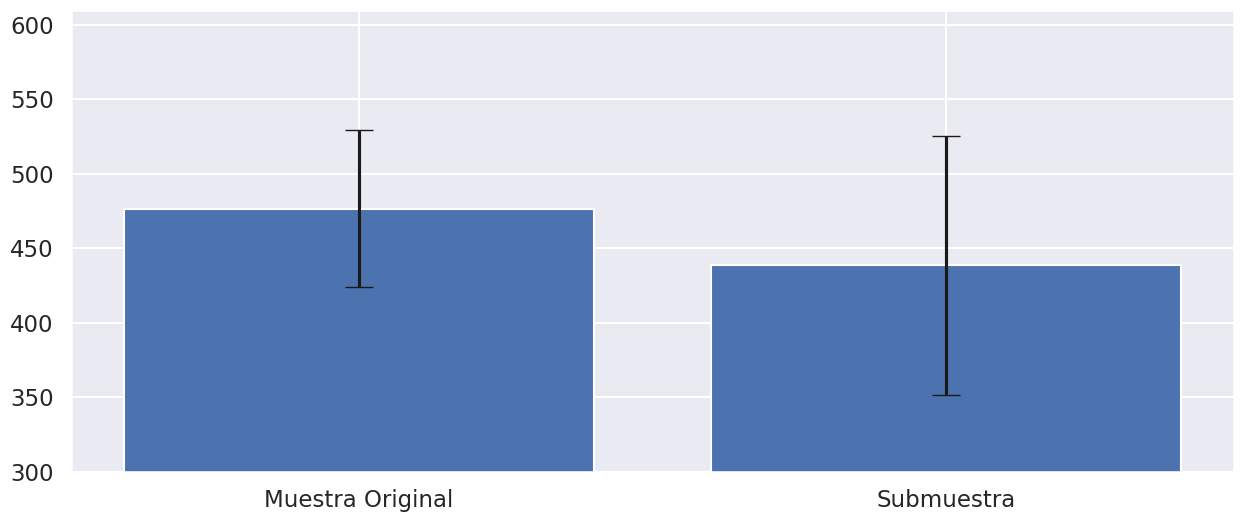

In [310]:
mediana1 = df_part_man.usd_monthly_gross_salary.median()
errores1 = df_part_man.usd_monthly_gross_salary.sem()
mediana2 = df_part_man_sub.usd_monthly_gross_salary.median()
errores2 = df_part_man_sub.usd_monthly_gross_salary.sem()

fig, ax = plt.subplots()
ax.bar(['Muestra Original', 'Submuestra'], [mediana1, mediana2], yerr=[errores1, errores2], capsize=10)
plt.ylim(300, 610)
plt.show()

Aunque las medianas no coinciden exactamente, como ocurria en el caso de los Full-time,se puede considerar que la submuestra es representativa de la muestra original, debido a la cercania entre ellas.

Sin embargo, un detalle a tener en cuenta es que los tamaños de las muestras son menores a 30, lo que significa que no alcanzan para suponer que siguen una distribucion normal. Por tal motivo, decimos que estamos tratando con pequeñas muestras, y vamos a considerar que siguen distribuciones t de Student.

In [311]:
group_man_p = df_part_man_sub.usd_monthly_gross_salary
group_not_man_p = df_part_not_man.usd_monthly_gross_salary

In [312]:
diferencia_medias_p = group_man_p.median() - group_not_man_p.median()
diferencia_medias_p

86.15759978651215

In [313]:
grad_de_lib_p = len(group_man_p) + len(group_not_man_p) - 2
grad_de_lib_p

44

In [314]:
t_valor_p = stats.t.ppf(1 - alpha/2, grad_de_lib_p)
t_valor_p

2.015367569912941

In [315]:
err_std_p = np.sqrt(group_man_p.var() + group_not_man_p.var()) / len(group_man_p)
err_std_p

22.453869407576793

In [316]:
inter_conf_t_stu_p = (diferencia_medias_p - t_valor_p * err_std_p, diferencia_medias_p + t_valor_p * err_std_p)
inter_conf_t_stu_p

(40.90479956342158, 131.4104000096027)

In [317]:
print(f"La diferencia de medias es {diferencia_medias_p:.0f}")
print(f"El intervalo de confianza del 95% para la diferencia de medias es ({inter_conf_t_stu_p[0]:.0f}, {inter_conf_t_stu_p[1]:.0f})")

La diferencia de medias es 86
El intervalo de confianza del 95% para la diferencia de medias es (41, 131)


Aunque estemos trabajando con muestras pequeñas, nuevamente obtenemos conclusiones parecidas a las de los Full-time. Vemos que, aun para aquellos que trabajan menos horas, hay una diferencia salarial entre varones cis y otros generos. Esta diferencia se encuentra entre los 40 y los  130 dolares aproximadamente.

El hecho de que el rango de valores sea mas grande que en el de los Full-time, se debe a que la precision del intervalo, baja al no tener tantas observaciones de las cuales extraer informacion.

## Ejercicio 2: Test de hipótesis



### 2.1 Formalización

Describir formalmente los distintos componentes de un test de hipótesis para comprobar si la distribución de los salarios es distinta entre los grupos A y B.
#### (ACLARACION : Cuando nos referimos a grupo A, nos referimos a los Varones Cis, mientras que cuando decimos Grupo B, nos referimos a otros generos.)

**Hipótesis Nula**

$H_0:...$ " La media salarial de programadores varones es igual a la media salarial de programadores mujeres y otras diversidades. " 

O bien: $ H_0 : \mu_1 - \mu_2 = 0 $ 

**Hipótesis Alternativa**

$H_a: ...$ " La media salarial de programadores varones es igual a la media salarial de programadores mujeres y otras diversiddes. "

O bien: $ H_a : \mu_1 - \mu_2 \neq 0 $ 

**Estadístico (Pivote)**

  * Identificar el estadístico
  * Escribir qué distribución tiene bajo $H_0$

El mejor estimador de la diferencia de medias poblacionales ($\mu_1 - \mu_2$) es la diferencia de medianas ($ Me_1 - Me_2 $). Por tanto, al probar si la diferencia en medias muestrales indica que la diferencia verdadera en medias poblacionales difiere de un valor especifico, ($\mu_1 - \mu_2$) = $D_0$, (que en este caso será $D_0 = 0 $), se puede usar el error estandar ES de ($ Me_1 - Me_2 $), estimado por :

$$ ES = \sqrt{\frac{s_1^2}{n_1}+\frac{s_2^2}{n_2}}$$

Dado que estamos trabajando con muestras de tamaños $n_1 , n_2 >> 30$, podemos suponer que el estimador tiene una distribución normal, debido al Teorema Central del Límite.

Por lo que el estadistico de prueba será

$$ z \approx \frac{( Me_1 - Me_2 ) - D_0}{\sqrt{\frac{s_1^2}{n_1}+\frac{s_2^2}{n_2}}} $$ 

O bien: 
$$ z \approx \frac{(Me_1 - Me_2)}{\sqrt{\frac{s_1^2}{n_1}+\frac{s_2^2}{n_2}}} $$ 


### 2.2 P-valor

1. Calcule el p-valor y decida si rechazar o no la hipótesis nula.
2. Interprete el resultado.

Links útiles:
* [Test de hipótesis usando scipy](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html)
* [Test de Welch](http://daniellakens.blogspot.com/2015/01/always-use-welchs-t-test-instead-of.html)

El valor p es una medida estadística que se utiliza en el test de hipótesis para evaluar la significancia de los resultados obtenidos. En el caso del test de Welch, el valor p indica la probabilidad de obtener un resultado tan extremo como el observado en las muestras, si la hipótesis nula (la suposición de que las dos poblaciones tienen medias iguales) fuera verdadera.

Para poder calcular el p-valor, o nivel de significancia observado de una prueba estadistica, podemos usar la funcion `ttest_ind` de la libreria scipy. Para esto procedemos de la siguiente manera.

In [318]:
from scipy.stats import ttest_ind

In [319]:
t_statistic, p_value = ttest_ind(group_man_f, group_not_man_f)
p_value

1.7441577241595026e-13

Una vez calculados los resultados, evaluamos la significancia estadistica. Si el valor p es menor que el nivel de significancia previamente establecido (alpha = 0.05), se rechaza la hipótesis nula y se concluye que las dos poblaciones tienen medias diferentes. En otras palabras, cuanto menor sea el valor p, mayor será la evidencia en contra de la hipótesis nula y más probable será que las dos muestras provengan de poblaciones diferentes.

In [320]:
if p_value < alpha:
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")

Rechazamos la hipótesis nula


Esto nos esta diciendo que los resultados son estadisticamente significativos, por lo que podemos decir que hay evidencia suficientes para concluir que las dos muestras tienen medias salariales diferentes, o bien, que los varones cis cobran mas que otros generos.

Ahora vamos a plasmar estos resultados en un grafico de barras para ver visualmente lo que hemos obtenido.

In [321]:
salarios_hombres = [group_man_f.median(), group_man_p.median()]
salarios_mujeres = [group_not_man_f.median(), group_not_man_p.median()]
categorias = ['Full-time', 'Part-time']


In [322]:
df_plot = pd.DataFrame({'Categorías': categorias,
                   'Hombres Cis': salarios_hombres,
                   'Otros Géneros': salarios_mujeres
                   })

df_plot = pd.melt(df_plot, id_vars='Categorías', var_name='Género', value_name='Salario')

In [323]:
df_plot

,Categorías,Género,Salario
0,Full-time,Hombres Cis,1144
1,Part-time,Hombres Cis,438
2,Full-time,Otros Géneros,853
3,Part-time,Otros Géneros,352


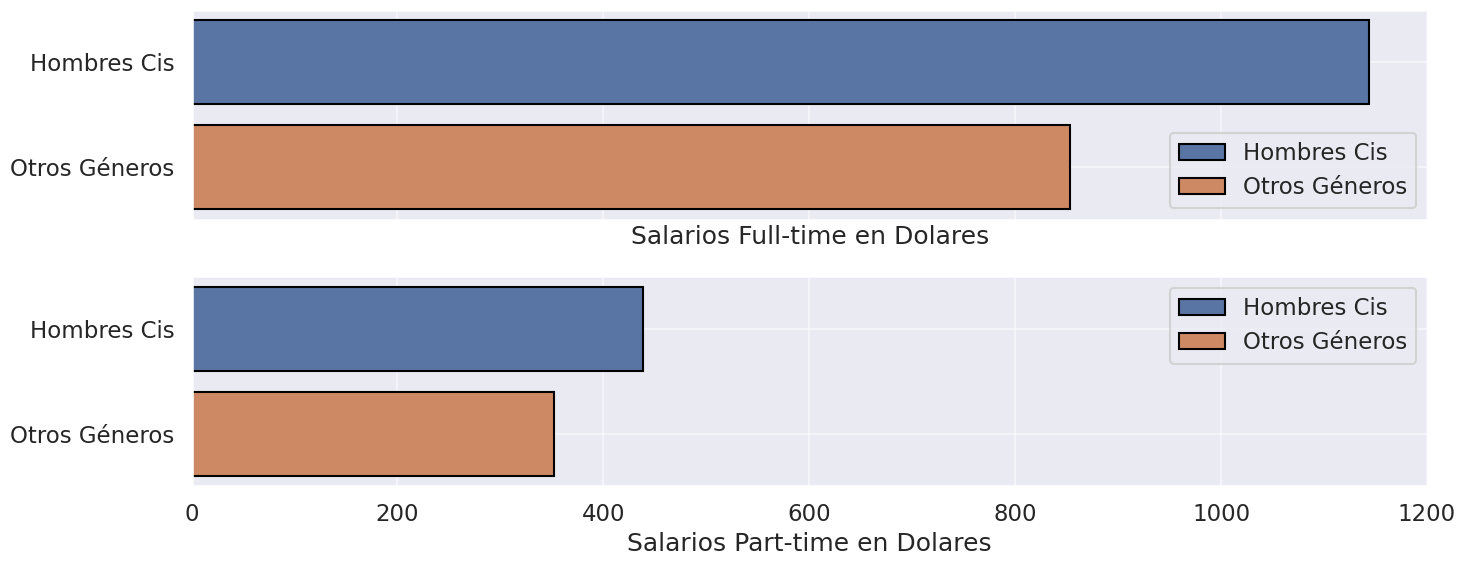

In [324]:
f, ax = plt.subplots(2, 1, figsize=(15,6), dpi=DPI, sharex=True)

df_name = ['Full-time', 'Part-time']

for i, da in enumerate(df_name):
    
    sns.barplot(df_plot[df_plot['Categorías'] == da],
                 x = 'Salario',
                 y = 'Género',
                 hue = 'Género',
                 ax=ax[i],
                 edgecolor='black',
                 orient = 'h',
                 dodge=False
                 )
    
    ax[i].grid(alpha=0.5)
    ax[i].legend()
    ax[i].set_ylabel(None)
    ax[i].set_xlabel(f'Salarios {da} en Dolares')
    
sns.set(font_scale=1.5)
fig.subplots_adjust(left=0.6, right=0.9, bottom=0.1, top=0.9)
plt.tight_layout()
plt.show()

### [Opcional] 2.3 Potencia del test

Nuestra muestra, ¿era lo suficientemente grande para detectar si existe o no una diferencia entre los grupos?

1. Utilice la función `tt_ind_solve_power` para calcular el tamaño necesario de la muestra para un poder estadístico de 0.8, 0.9 y 0.95, asumiendo una significancia estadística de 0.05.
2. ¿Cómo intepretan el poder estadístico de un test? Dado su conocimiento de dominio sobre los datos, ¿les parece que esta muestra es lo suficientemente grande para ser representativo de la tendencia general? ¿y para utilizarlo en un juicio penal contra una empresa XX por una causa de discriminación?

[Documentación](https://www.statsmodels.org/stable/generated/statsmodels.stats.power.tt_ind_solve_power.html)

NOTA: este análisis debería hacerse ANTES de recolectar los datos.

In [325]:
from statsmodels.stats.power import tt_ind_solve_power

In [326]:
effect_size = (group_man_f.median() - group_not_man_f.median()) / group_not_man_f.std()
ratio = len(group_not_man_f) / len(group_man_f)
power= 0.8

In [327]:
tt_ind_solve_power(effect_size=effect_size, alpha=alpha,power=power,  ratio=ratio)

98.91097152025962

## Ejercicio 3: Comunicación y visualización

**Consigna:** Seleccionen un resultado que les parezca relevante a partir de alguno de los ejercicios del entregable. Diseñe e implemente una comunicación en base a este mensaje, en un archivo PDF.

Elija las palabras y visualización más adecuada para que la comunicación sea entendible, efectiva y se dapte a UNA de las siguientes situaciones:

1. Una sección en un artículo de difusión a presentar como parte de una organización sin fines de lucro.
No más de 1 página A4 (o dos si los gráficos son muy grandes).
  1. Ejemplo: Alguna de las secciones [Los ecosistemas de emprendimiento de América Latina y el Caribe frente al COVID-19: Impactos, necesidades y recomendaciones](https://publications.iadb.org/es/los-ecosistemas-de-emprendimiento-de-america-latina-y-el-caribe-frente-al-covid-19-impactos-necesidades-y-recomendaciones), por ejemplo la sección *2.2. Reacciones de los emprendedores*.
  2. Ejemplo: Alguna de las secciones de [The state of gender pay gap in 2021](https://www.payscale.com/data/gender-pay-gap?tk=carousel-ps-rc-job)
  3. Puntos clave: 
    1. Simpleza de los gráficos.
    2. Comunicación en lenguaje simple a personas que no son necesariamente expertos de dominio.
    2. Selección de UNA oración sobre la que se hace énfasis.
    3. No es necesario que mencionen objetivos ni descripciones del conjunto de datos, se supone que eso ya estaría explicado en otras secciones del informe.

2. Una publicación científica o reporte técnico interno. No más de una página A4:
  2. Ejemplo: La sección de resultados de [IZA DP No. 12914: The Impact of a Minimum Wage Change on the Distribution of Wages and Household Income](https://www.iza.org/publications/dp/12914/the-impact-of-a-minimum-wage-change-on-the-distribution-of-wages-and-household-income).
  2. Ejemplo: Alguna de las secciones de [Temporary reduction in daily global CO2 emissions during the COVID-19 forced confinement](https://www.nature.com/articles/s41558-020-0797-x)
  3. Puntos clave:
    3. Nivel de detalle técnico requerido. Es necesario justificar la validez del análisis.
    4. La idea presentada puede ser más compleja. Pueden asumir que la audiencia tiene conocimiento técnico y va a analizar las visualizaciones en detalle. 
    5. Pueden presentar más en detalle las limitaciones del análisis (significancia estadística, etc.)
    2. No es necesario que mencionen objetivos ni descripciones del conjunto de datos, se supone que eso ya estaría explicado en otras secciones del informe.

3. Un tweet (o post de LinkedIn) para la cuenta de su empresa consultora que hace análisis de datos. El objetivo es promocionar un análisis de datos abiertos que van a incluir en su portfolio:
  1. Ejemplo: [Comparación vacunas covid](https://twitter.com/infobeautiful/status/1381577746527236098?s=20)
  2. Ejemplo: [Tweet del BID](https://twitter.com/el_BID/status/1388508583944507396?s=20). Lo valioso de este tweet es que usaron un único número para transmitir un mensaje. Puede ser algo así, o con un gráfico muy simple.
  3. Ejemplo: [Cambio climático](https://twitter.com/UNFCCC/status/1387732156190011394?s=20) Es un muy buen ejemplo, excepto que el gráfico no se lee nada y hay que entrar a la publicación original.
  3. Ejemplo: [¿Cuánto están los programadores en las empresas?](https://www.linkedin.com/posts/denis-rothman-0b034043_tech-career-work-activity-6793861923269054464-gS6y) (No verificamos la veracidad o seriedad de la fuente).
  4. Puntos clave:
    1. Su audiencia no va a mirar la visualización por más de unos segundos, y no tiene conocimiento técnico.
  3. Tienen que incluir además una *breve* descripción de cómo obtuvieron los datos que están presentando, que no entraría en el tweet.
